### 乳がん診断データセット
Breast Cancer Wisconsin (Diagnostic) Data Setに由来し、乳腺腫瘤の穿刺吸引細胞診のデジタル画像から計算されたデータ。

In [1]:
# データの確認
import pandas as pd

df = pd.read_csv('./data/cancer.csv')

df.head()

,target,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


>最初のtargetカラムは、乳がんの診断結果。
>
>良性（Benign）は0、悪性（Malignant）は1 としてラベル付け。
>
>それに続いて、乳がんの診断に用いた検査結果が続く。

### 説明変数と目的変数
今回、良性は0、悪性は1のラベル付けがされているため、**２クラス分類モデル** になります。

特徴量を選ぶ際、どれが乳がんの特徴を表しているわからない。

そこで、target以外の項目を説明変数にして、2値分類モデルを作成する。


In [2]:
# 説明変数と目的変数の設定
import pandas as pd

df = pd.read_csv('./data/cancer.csv')

X = df[df.columns[1:]]  # target 以外
y = df['target']

print(f'データ数: {len(df)}, 説明変数の次元 {X.shape[1]}')

データ数: 569, 説明変数の次元 30


>**次元とは**
>
>データセット内の各特徴（特徴量）の数を指す。
>
>次元の増加は多くの特徴を含むことを意味し、高次元空間では以下のような現象が起きる
>- **高次元の呪い** : 次元が増えると、データがスパース（まばら）になり、モデルの学習やパフォーマンスが難しくなること。
>- **次元削減** : 次元を減らす技術（PCAやt-SNEなど）を使い、重要な特徴を保持しつつモデルの効率を上げる。


###  次元削減による高次元データの散布図
人間は2次元、もしくは３次元しか視覚的に理解できないため、
散布図も２次元、頑張っても３次元のデータまでしか描画できない。

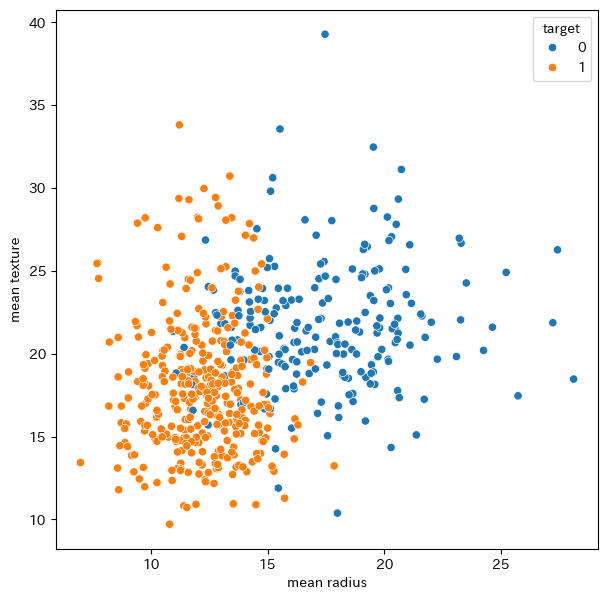

In [3]:
# 2次元の散布図の描画
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
import seaborn as sns

df = pd.read_csv('./data/cancer.csv')
plt.figure(figsize=(7, 7))
sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='target')
plt.show()



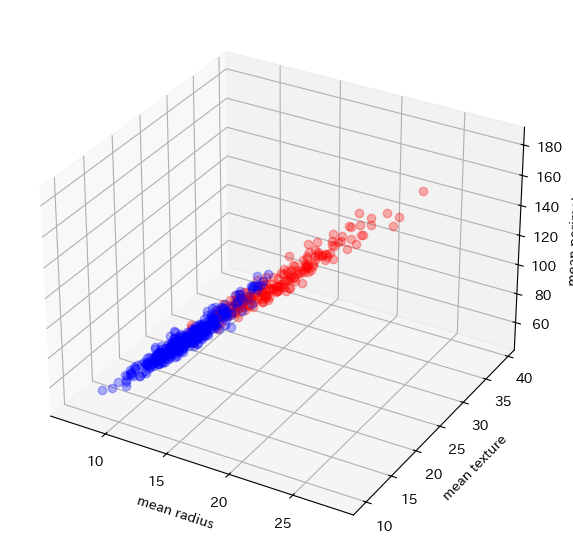

In [4]:
# 3次元の散布図の描画
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D


df = pd.read_csv('./data/cancer.csv')

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d') # 明示的に3Dプロジェクションを指定
ax.set_xlabel("mean radius")
ax.set_ylabel("mean texture")
ax.set_zlabel("mean perimeter")
colors=['r', 'b']
for i, gd in enumerate(df.groupby('target')):
    ax.plot(gd[1]['mean radius'], gd[1]['mean texture'], gd[1]['mean perimeter'],
            marker="o", linestyle='None', c=colors[i], alpha=0.3)
    
plt.show()

>
>

>3次元のデータを散布図に収めても、全てのデータの散らばりはいえない。



### 次元削減
30次元のデータを重要な特徴量を残しながら、次元を落とす方法。


   target          PC1         PC2
0       0  1160.142574 -293.917544
1       0  1269.122443   15.630182
2       0   995.793889   39.156743
3       0  -407.180803  -67.380320
4       0   930.341180  189.340742


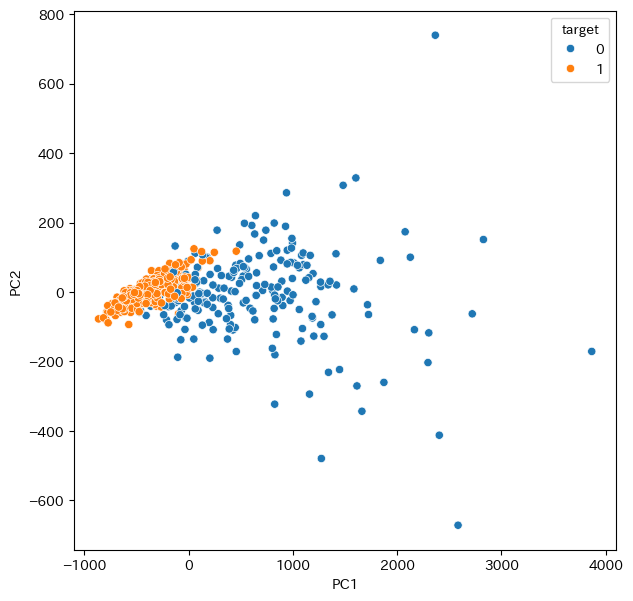

In [5]:
# 主成分分析（PCA）による次元削減と散布図の描画
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
from sklearn.decomposition import PCA
import seaborn as sns

df = pd.read_csv('./data/cancer.csv')
X = df[df.columns[1:]]  # target 以外
y = df['target']

pca = PCA(n_components=2)  # 2次元に削減
df2 = pd.DataFrame(pca.fit_transform(X), columns=['PC1', 'PC2'])
df2 = pd.concat([df[['target']], df2], axis=1)
print(df2.head())

plt.figure(figsize=(7, 7))
sns.scatterplot(data=df2, x='PC1', y='PC2', hue='target')
plt.show()


### スケーリング
データセットは、さまざまな検査結果が含まれていますが、それぞれ単位が異なる。

各カラムごとに最大値や最小値も大きくばらついている。

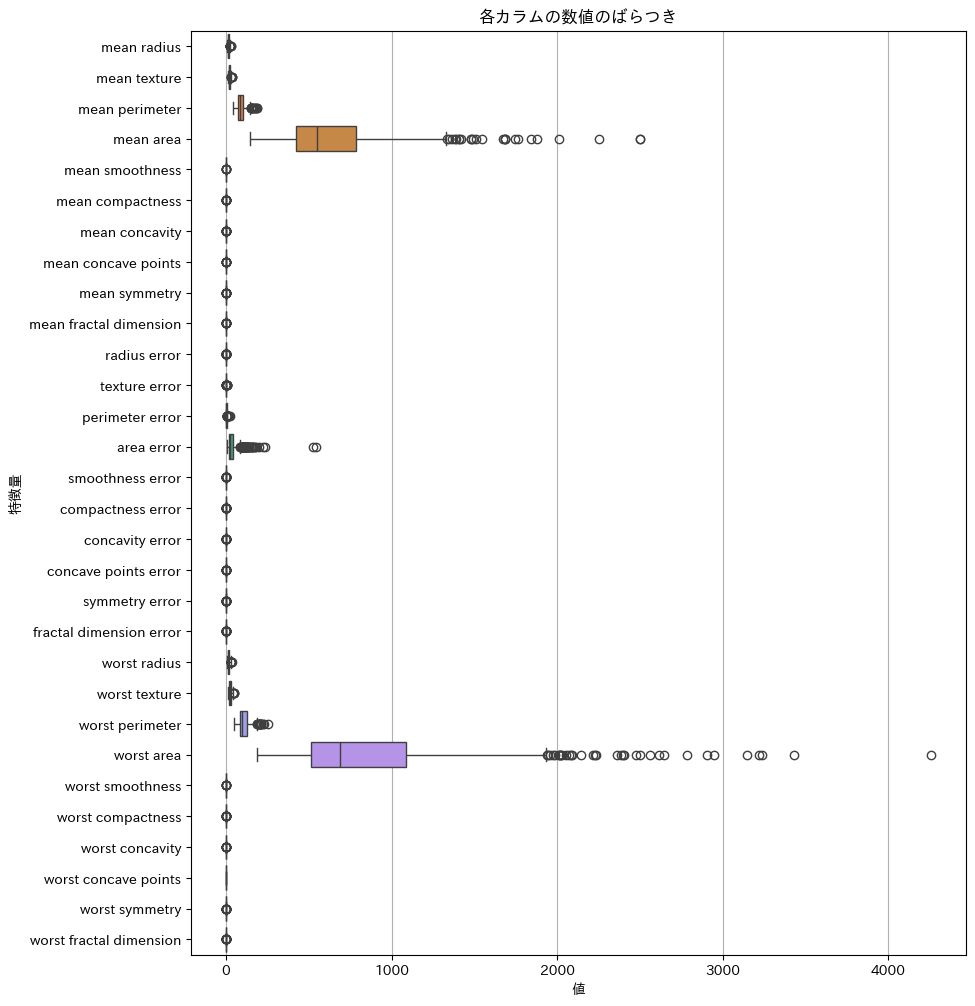

In [6]:
# 各カラムの数値のばらつきを確認するための箱ひげ図の描画
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
df = pd.read_csv('./data/cancer.csv')

# カラム名をy軸にした箱ひげ図（横向き）
plt.figure(figsize=(10, 12))
sns.boxplot(data=df[df.columns[1:]], orient='h')  # target以外を横向きで描画
plt.title('各カラムの数値のばらつき')
plt.xlabel('値')
plt.ylabel('特徴量')
plt.grid(axis='x')
plt.show()


データ分析では、大きな値の説明変数があると、小さな値の説明変数の影響が小さくなることがある。

そのような影響を排除するため、スケーリングを行う。

標準化: サンプル値 $x$ から平均 $\bar{x}$ を引き、標準偏差 $σ$ で割る
$$ z = \frac{x-\bar{x}}{σ} $$

sklearnモジュールでは、簡単にスケーリングを行うための道具が`StandardScaler`クラスとして提供されています。

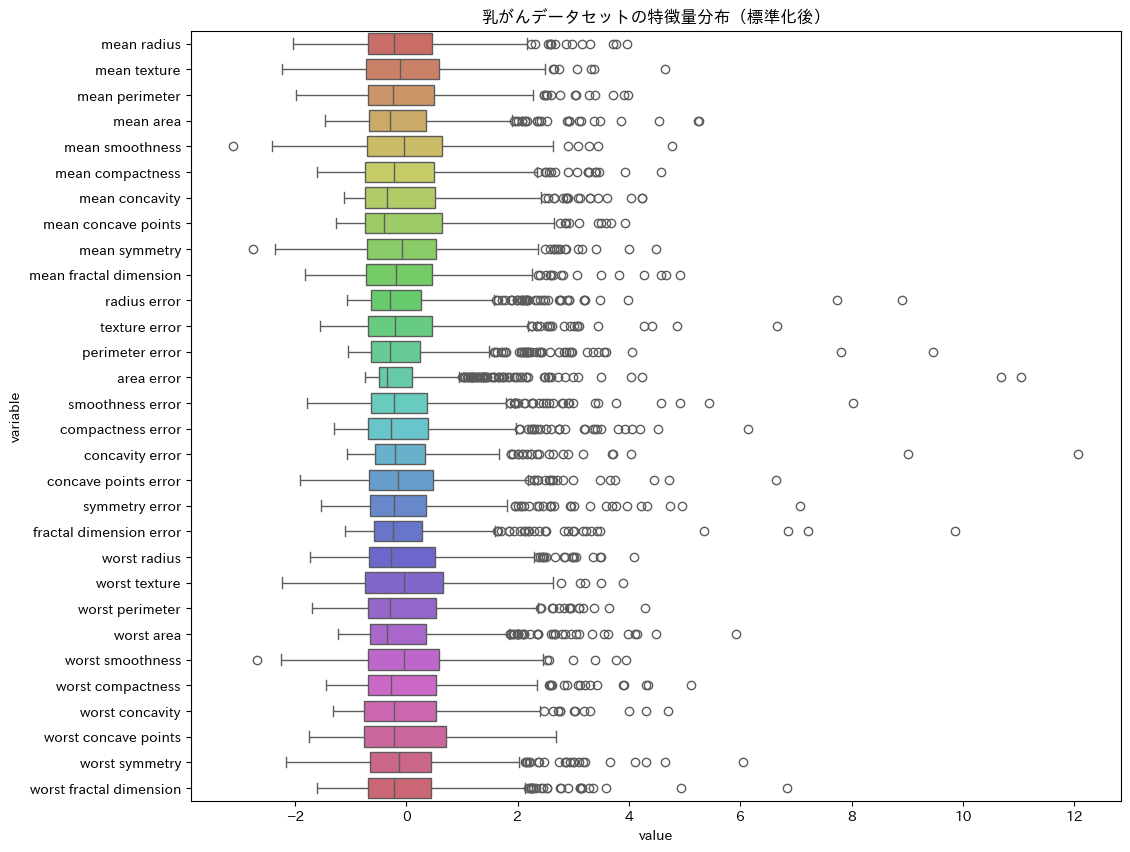

In [7]:
# スケーリングを行う

import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns


df = pd.read_csv('./data/cancer.csv')

# 1. 標準化 (targetは除外)
features = df.drop(columns=['target'])
sc = StandardScaler()
X_scaled = sc.fit_transform(features)

# ataFrameに戻す
df_scaled = pd.DataFrame(X_scaled, columns=features.columns)

# 描画用にデータを「縦持ち」に変換 (melt)
# これにより、Seabornが高速に処理できるようになります
df_melted = df_scaled.melt()

plt.figure(figsize=(12, 10))

# xに値(value)、yに変数名(variable)を指定することで水平表示
sns.boxplot(data=df_melted, x='value', y='variable', hue='variable', palette='hls')
plt.title("乳がんデータセットの特徴量分布（標準化後）")
plt.show()

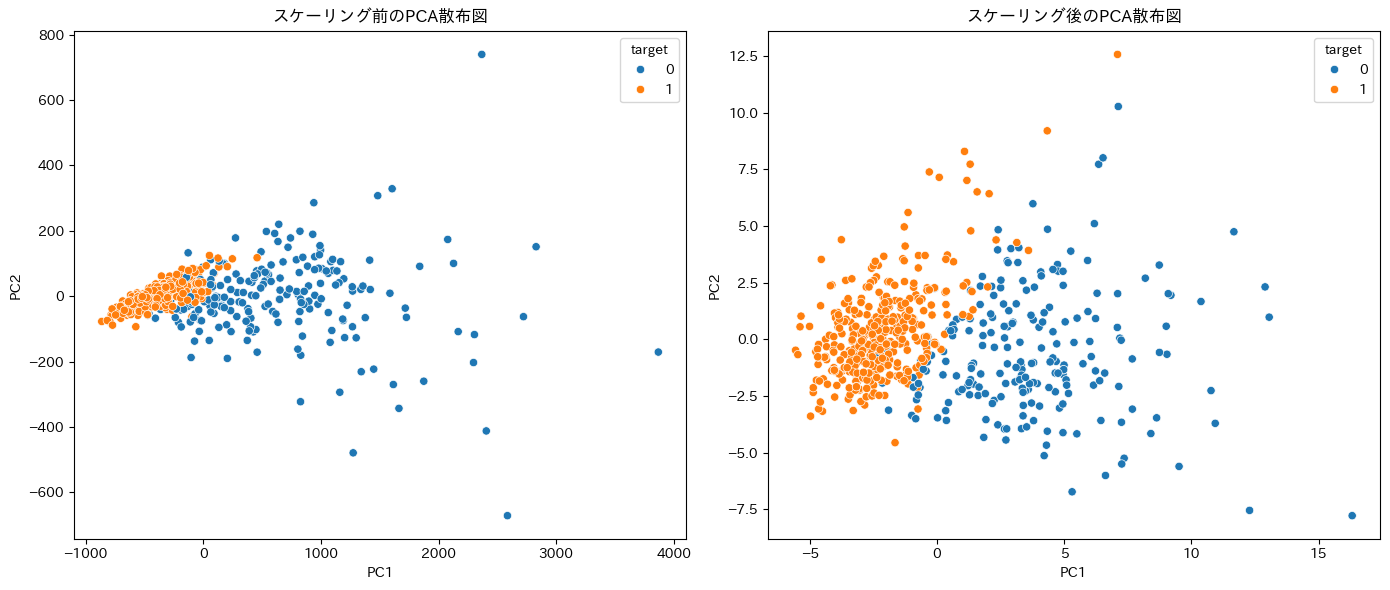

In [8]:
# スケーリング+主成分分析（PCA）による次元削減と散布図の描画
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('./data/cancer.csv')
X = df[df.columns[1:]]  # target 以外
y = df['target']

# 1. 標準化
sc = StandardScaler() # StandardScalerのインスタンスを作成
X_scaled = sc.fit_transform(X) # target以外の特徴量を標準化

# 2. PCAで次元削減
pca = PCA(n_components=2)  # 2次元に削減
df2 = pd.DataFrame(pca.fit_transform(X_scaled), columns=['PC1', 'PC2']) # PCAの結果をDataFrameに変換
df2 = pd.concat([df[['target']], df2], axis=1) # 元のtarget列とPCAの結果を結合して新しいDataFrameを作成


# スケーリング前とスケーリング後のPCA散布図を並べて表示
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # 1行2列のサブプロットを作成


# スケーリング前のPCA散布図
pca_before = PCA(n_components=2) # スケーリング前のデータに対してPCAを適用
df_before = pd.DataFrame(pca_before.fit_transform(X), columns=['PC1', 'PC2']) # スケーリング前のPCAの結果をDataFrameに変換
df_before = pd.concat([df[['target']], df_before], axis=1) # 元のtarget列とスケーリング前のPCAの結果を結合して新しいDataFrameを作成
sns.scatterplot(data=df_before, x='PC1', y='PC2', hue='target', ax=axes[0]) # スケーリング前のPCA散布図を左のサブプロットに描画
axes[0].set_title('スケーリング前のPCA散布図')


# スケーリング後のPCA散布図
sns.scatterplot(data=df2, x='PC1', y='PC2', hue='target', ax=axes[1])
axes[1].set_title('スケーリング後のPCA散布図')
plt.tight_layout()
plt.show()


#### ホールドアウト法で訓練データとテストデータを分割

In [9]:
# ホールドアウト法によるデータの分割

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('./data/cancer.csv')
X = df[df.columns[1:]]  # target 以外
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0) # データを訓練用とテスト用に分割

print(f'訓練データ数: {len(X_train)}, テストデータ数: {len(X_test)}')

訓練データ数: 398, テストデータ数: 171


### 分類モデルと分類器(Classifier)

クラス分類とは、データをあらかじめ定義されたカテゴリ（クラス）に分類する機械学習の手法。

具体的には、入力データを分析して、そのデータがどのクラスに属するかを予測。

>- メールを「スパム」か「非スパム」に分類する。
>- 画像を「猫」、「犬」、「鳥」に分類する。
>- 医療データを使って、「病気あり」か「病気なし」に分類する。

### 回帰モデルと分類モデルの違い
大きな違いは、機械学習モデルの出力形式

- **数値（量）データ** : 回帰モデル
- **カテゴリカルデータ** : クラス分類モデル

### クラス分類アルゴリズム

sklearnには、次のようなクラス分類アルゴリズムが簡単に利用できるようになっている。

1. ロジスティック回帰
2. 決定木
3. ランダムフォレスト
4. サポートベクターマシン
5. ナイーブベイズ
6. 多層パーセプトロン(MLP)

#### ロジスティック回帰
`sklearn.linear_model.LogisticRegression`

- 確率を予測し、その確率に基づいてデータがどのクラスに属するかを決定する。
- シグモイド関数を用いて、出力が0から1の範囲に収まるように変換する。

>線形回帰の確率的な予測出力とシグモイド関数(ロジスティック関数)を組み合わせることで、カテゴリー値に変換する。
> $$ σ(x) = \frac{1}{1+e^{-z}} $$


#### 決定木
`sklearn.tree.DecisionTreeClassifier`

- 決定木は、条件分岐によってグループを分割して分類する手法。
- グループがなるべく同じような属性で構成されるように分割。

`Regressor` の代わりに`Classifier`を使う。

回帰木
```python
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
```

分類木
```python
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
```



#### ランダムフォレスト
`sklearn.ensemble.RandomForestClassifier`

- 分類や回帰に使える機械学習の手法。
- 決定木をたくさん作って多数決する（または平均を取る）ような手法。
- ランダムフォレストは大量のデータを必要としますが、精度の高い予測/分類を行えるという特徴がある。

#### サポートベクターマシン（SVC)

` sklearn.svm.LinearSVC `

- パターン認識モデルの一つで、線形入力素子を利用して2クラスのパターン識別器を構成する手法。
- 2つのグループ間の最も距離の離れた箇所（最大マージン）を見つけ出し、その真ん中に識別の線を引く。

#### ナイーブベイズ分類器

`sklearn.naive_bayes.GaussianNB`

- 特徴間に強い（ナイーブな）独立性を仮定した上でベイズの定理を使う、確率に基づいたアルゴリズム。

#### 多層パーセプトロン(MLP)
` sklearn.neural_network.MLPClassifier `

- 人間の脳（ニューロン）の数理モデルに基づくアルゴリズム。
- 深層学習に用いられている。


In [10]:
# 決定木による分類

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


df = pd.read_csv('./data/cancer.csv')
X = df[df.columns[1:]]  # target 以外
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0) # データを訓練用とテスト用に分割

print(f'訓練データ数: {len(X_train)}, テストデータ数: {len(X_test)}')

# 決定木による分類

model = DecisionTreeClassifier(random_state=0) # 決定木分類器のインスタンスを作成
model.fit(X_train, y_train) # 訓練データを使ってモデル

y_pred = model.predict(X_test) # テストデータを使って予測
print('\n予測結果:', y_pred)
print('\n正解ラベル:', y_test.values) # テストデータの正解ラベルを表示


訓練データ数: 398, テストデータ数: 171

予測結果: [0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 0 0 0 0 1 1 0 1 1 0 1 0 1 1 1 0 1 0 1
 0 1 0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 1 1 0 0 0 0 0 1 1 0 1 1
 0 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1 1 1 1 1 0 0 1 0 1 0 1 1
 0 0 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 0
 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 0 1 0 0 0 1 1 1]

正解ラベル: [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 1 0 1 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 1 1 1 1 1 0 0 0 1 1 0 1 0 0 0 1 1 0 1 0
 0 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 1 0 1 1 0 1 1 1 1 1 1 1 0 1 0 1 0 0 1
 0 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 0
 1 1 1 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 0 0 1 1 1]


### モデル評価
#### 混合行列

クラス分類器が出した予測結果と実際の結果を全て網羅したもの。

Pythonで混同行列を求めるには、`sklearn.metrics`モジュールの`confusion_matrix()`を用いる。

第一引数に実測クラス（正解クラス）、第二引数に予測したクラスを指定。

訓練データ数: 398, テストデータ数: 171

予測結果: [0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 0 0 0 0 1 1 0 1 1 0 1 0 1 1 1 0 1 0 1
 0 1 0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 1 1 0 0 0 0 0 1 1 0 1 1
 0 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1 1 1 1 1 0 0 1 0 1 0 1 1
 0 0 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 0
 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 0 1 0 0 0 1 1 1]

正解ラベル: [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 1 0 1 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 1 1 1 1 1 0 0 0 1 1 0 1 0 0 0 1 1 0 1 0
 0 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 1 0 1 1 0 1 1 1 1 1 1 1 0 1 0 1 0 0 1
 0 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 0
 1 1 1 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 0 0 1 1 1]

混合行列:
 [[59  4]
 [11 97]]

混合行列の意味:
cm[0, 0]: 59  真陽性 (TP:True Positive) - クラス1を正しくクラス1と予測した数
cm[0, 1]: 4  偽陰性 (FN:False Negative) - クラス1を誤ってクラス0と予測した数
cm[1, 0]: 11  偽陽性 (FP:False Positive) - クラス0を誤ってクラス1と予測した数
cm[1, 1]: 97  真陰性 (TN:True Negative) - クラス0を正しくクラス0

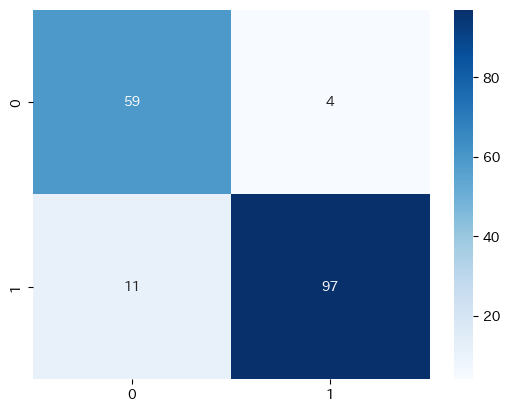

In [11]:
# 決定木による分類と、混合行列の表示

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns


df = pd.read_csv('./data/cancer.csv')
X = df[df.columns[1:]]  # target 以外
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0) # データを訓練用とテスト用に分割

print(f'訓練データ数: {len(X_train)}, テストデータ数: {len(X_test)}')

# 決定木による分類

model = DecisionTreeClassifier(random_state=0) # 決定木分類器のインスタンスを作成
model.fit(X_train, y_train) # 訓練データを使ってモデル

y_pred = model.predict(X_test) # テストデータを使って予測
print('\n予測結果:', y_pred)
print('\n正解ラベル:', y_test.values) # テストデータの正解ラベルを表示

# 混合行列の表示
cm = confusion_matrix(y_test, y_pred) # 混合行列を計算
print('\n混合行列:\n', cm)
print('\n混合行列の意味:')
print(f'cm[0, 0]: {cm[0, 0]}  真陽性 (TP:True Positive) - クラス1を正しくクラス1と予測した数')
print(f'cm[0, 1]: {cm[0, 1]}  偽陰性 (FN:False Negative) - クラス1を誤ってクラス0と予測した数')
print(f'cm[1, 0]: {cm[1, 0]}  偽陽性 (FP:False Positive) - クラス0を誤ってクラス1と予測した数')
print(f'cm[1, 1]: {cm[1, 1]}  真陰性 (TN:True Negative) - クラス0を正しくクラス0と予測した数')


# 混合行列をヒートマップで表示
sns.heatmap(cm, annot=True, cmap='Blues')
plt.show()



### 定量的な評価指標
- 正解率（accuracy）
- 適合率（precision, PPV）
- 再現率（recall, sensitivity, hit rate, TPR）
- F値（F-measure, F-score, F1-score ）

#### 正解率(accuracy)
全てのサンプルに対する正解したサンプルの割合

`sklearn.metrics`モジュールの`accuracy_score()`で算出。

機械学習では、最も一般的に性能評価で用いられる指標。
$$ \frac{TP+TN}{TP+FP+FN+TN} $$


#### 適合度(Precision)
適合率（precision）は、陽性と予測されたサンプルのうち正解したサンプルの割合。

`sklearn.metrics`モジュールの`precision_score()`で算出。


FP（偽陽性）が大きくなると適合率は小さくなるので、偽陽性を避けたい場合に用いる。
$$ \frac{TP}{TP+FP} $$


#### 再現率(Recall)

再現率（recall）は実際に陽性のサンプルのうち正解したサンプルの割合。

`sklearn.metrics`モジュールの`recall_score()`で算出。


FN（偽陰性）が大きくなると再現率は小さくなるので、偽陰性を避けたい場合に用いる。

$$ \frac{TP}{TP+FN} $$



#### F値 (F1-measure)

適合率と再現率の調和平均。

`sklearn.metrics`モジュールの`recall_score()`で算出。


$$ \frac{TP × 2}{TP×2+FP+FN} $$



In [12]:
# 決定木による分類と、各評価指数を算出

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score





df = pd.read_csv('./data/cancer.csv')
X = df[df.columns[1:]]  # target 以外
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0) # データを訓練用とテスト用に分割

print(f'訓練データ数: {len(X_train)}, テストデータ数: {len(X_test)}')

# 決定木による分類

model = DecisionTreeClassifier(random_state=0) # 決定木分類器のインスタンスを作成
model.fit(X_train, y_train) # 訓練データを使ってモデル

y_pred = model.predict(X_test) # テストデータを使って予測


# 混合行列の表示
cm = confusion_matrix(y_test, y_pred) # 混合行列を計算
print('\n混合行列:\n', cm)
print('\n混合行列の意味:')
print(f'cm[0, 0]: {cm[0, 0]}  真陽性 (TP:True Positive) - クラス1を正しくクラス1と予測した数')
print(f'cm[0, 1]: {cm[0, 1]}  偽陰性 (FN:False Negative) - クラス1を誤ってクラス0と予測した数')
print(f'cm[1, 0]: {cm[1, 0]}  偽陽性 (FP:False Positive) - クラス0を誤ってクラス1と予測した数')
print(f'cm[1, 1]: {cm[1, 1]}  真陰性 (TN:True Negative) - クラス0を正しくクラス0と予測した数')


# 正解率の算出
accuracy = accuracy_score(y_test, y_pred) 
print(f'\n正解率: {accuracy:.4f} (全体のうち、正しく予測した割合)')

# 適合率の算出
precision = precision_score(y_test, y_pred)
print(f'適合率: {precision:.4f} (予測が正とされたうち、実際に正であった割合)')

# 再現率の算出
recall = recall_score(y_test, y_pred)
print(f'再現率: {recall:.4f} (実際に正であったもののうち、正しく予測された割合)')

# F1スコアの算出
f1 = f1_score(y_test, y_pred)
print(f'F1スコア: {f1:.4f} (適合率と再現率の調和平均)')

# 調和平均とは、2つの数値のバランスを取るための平均値で、特に適合率と再現率のように、両方が重要な場合に使用されます。
# F1スコアは、適合率と再現率の両方が高いほど高くなりますが、どちらか一方が低いとF1スコアも低くなります。


訓練データ数: 398, テストデータ数: 171

混合行列:
 [[59  4]
 [11 97]]

混合行列の意味:
cm[0, 0]: 59  真陽性 (TP:True Positive) - クラス1を正しくクラス1と予測した数
cm[0, 1]: 4  偽陰性 (FN:False Negative) - クラス1を誤ってクラス0と予測した数
cm[1, 0]: 11  偽陽性 (FP:False Positive) - クラス0を誤ってクラス1と予測した数
cm[1, 1]: 97  真陰性 (TN:True Negative) - クラス0を正しくクラス0と予測した数

正解率: 0.9123 (全体のうち、正しく予測した割合)
適合率: 0.9604 (予測が正とされたうち、実際に正であった割合)
再現率: 0.8981 (実際に正であったもののうち、正しく予測された割合)
F1スコア: 0.9282 (適合率と再現率の調和平均)


### 決定木の原理

決定木は、データを分類するためのシンプルながら強力なモデル。

決定木は、質問を繰り返し尋ねることで答え（予測）を導き出すプロセスに似ている。


#### 例：動物の分類

動物は「鳥」「哺乳類」「爬虫類」の3つのカテゴリーに分類される。

分類するための特徴（属性）には「羽があるか」「乳を飲むか」「卵を産むか」がある。

##### 1. データセット

| 動物 | 羽がある | 乳を飲む | 卵を産む | カテゴリー |
|------|---------|-----------|---------|------------|
| 動物A | はい   | いいえ    | はい     | 鳥         |
| 動物B | いいえ | はい      | いいえ   | 哺乳類      |
| 動物C | いいえ | いいえ    | はい     | 爬虫類      |
| 動物D | はい   | いいえ    | はい     | 鳥          |
| 動物E | いいえ | はい      | いいえ   | 哺乳類      |

##### 2. ルートノードの選択と分割基準の適用

決定木の構築を始めるにあたり、最初に「どの特徴が最も情報量が多いか、つまり、最も良い分割を提供するか を決定する。

ここでは、「羽がある」特徴を最初の質問として選ぶ。なぜなら、この特徴が最も明確に動物を分類できるから。

- 質問: 羽がありますか？
    - はいの場合: 動物は「鳥」。
    - いいえの場合: 次の質問へ進む。

##### 3. リーフノードの生成
「羽がある」=「はい」の動物はすでに「鳥」として分類された。

残りの動物に対して、次の特徴「乳を飲む」を質問として適用する。

- 質問: 乳を飲みますか？
    - はいの場合: 動物は「哺乳類」。
    - いいえの場合: 動物は「爬虫類」。

##### 4. リーフノードの生成
このプロセスを通じて、決定木が完成する。

この決定木を使って、新しい動物がどのカテゴリーに属するかを予測することができる。

例えば、羽があり乳を飲まず卵を産む動物は「鳥」に分類される。



>決定木の応用範囲は、医療、金融、マーケティングなど多岐にわたる。
>
>また、決定木は、ランダムフォレストや勾配ブースティングなどのアンサンブル学習の基礎としても重要な役割を果たしている。
>
>これらのアンサンブル学習は、複数の決定木を組み合わせることで、単一の決定木よりも優れた予測性能を達成する。

訓練データ数: 398, テストデータ数: 171


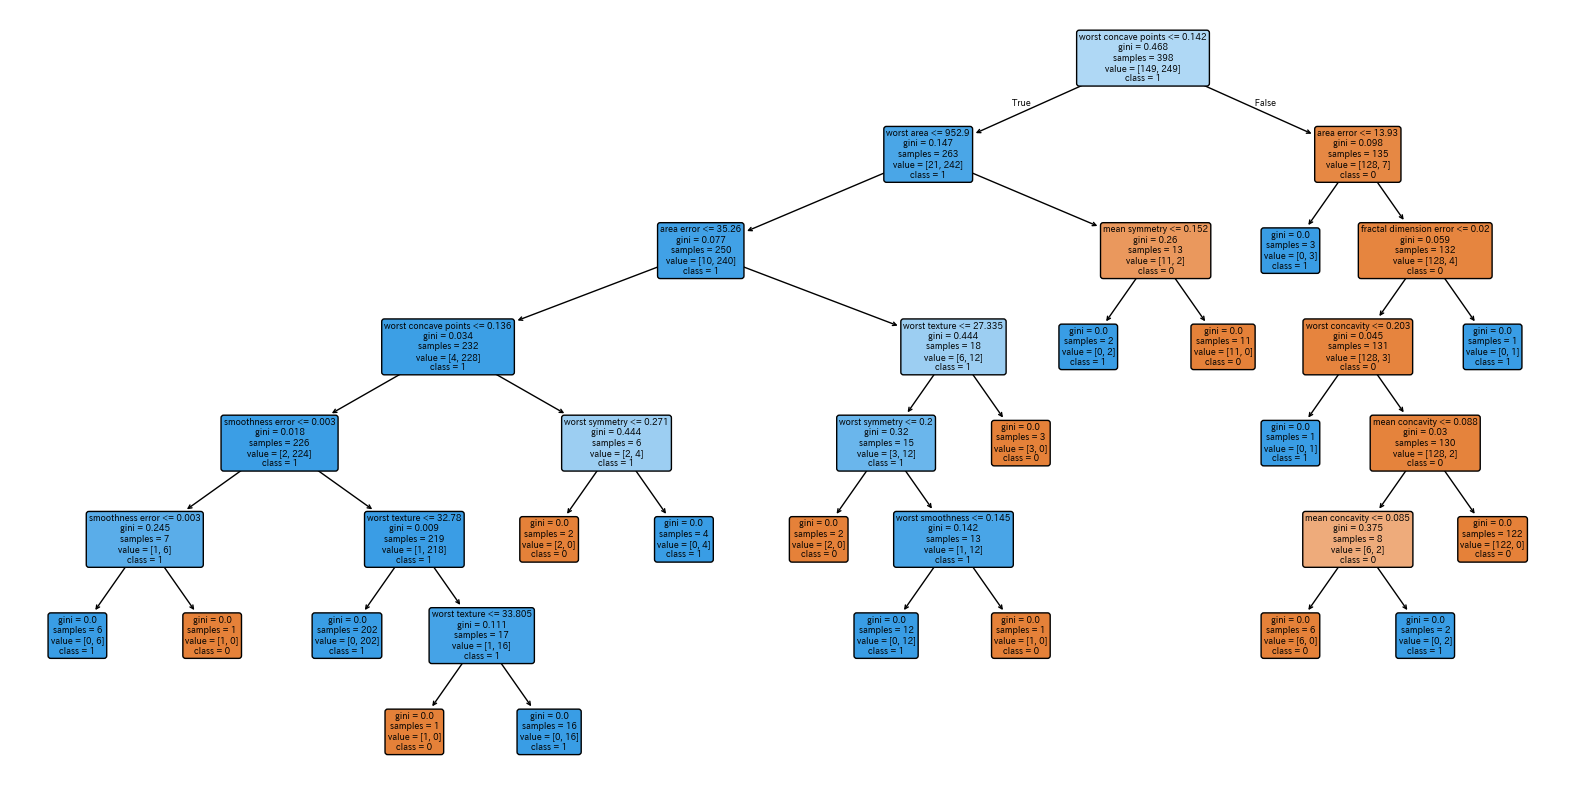

In [13]:
# 決定木による分類と、決定木の描画

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


df = pd.read_csv('./data/cancer.csv')
X = df[df.columns[1:]]  # target 以外
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0) # データを訓練用とテスト用に分割

print(f'訓練データ数: {len(X_train)}, テストデータ数: {len(X_test)}')

# 決定木による分類

model = DecisionTreeClassifier(random_state=0 ) # 決定木分類器のインスタンスを作成
model.fit(X_train, y_train) # 訓練データを使ってモデル


# 決定木の描画
plt.figure(figsize=(20, 10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=['0', '1'], rounded=True)
plt.show()


### 説明可能なAI(XAI)
決定木は、**説明可能なAI（XAI：Explainable Artificial Intelligence）** の分野で非常に重要な役割を果たす。

XAIの主な目的は、機械学習モデルの予測を人間が理解しやすくすること。

これにより、モデルの透明性が高まり、エンドユーザーがモデルの予測に対する信頼を築くことができる。

決定木はその直感的な理解のしやすさから、XAIの中心的なツールの一つとなっている。

決定木モデルの学習が終わると、`feature_importances_`に各説明変数ごとの重要度が算出されて記録されている。

訓練データ数: 398, テストデータ数: 171
mean radius 0.00000
mean texture 0.00000
mean perimeter 0.00000
mean area 0.00000
mean smoothness 0.00000
mean compactness 0.00000
mean concavity 0.02112
mean concave points 0.00000
mean symmetry 0.01815
mean fractal dimension 0.00000
radius error 0.00000
texture error 0.00000
perimeter error 0.00000
area error 0.04749
smoothness error 0.01059
compactness error 0.00000
concavity error 0.00000
concave points error 0.00000
symmetry error 0.00000
fractal dimension error 0.01016
worst radius 0.00000
worst texture 0.02784
worst perimeter 0.00000
worst area 0.08615
worst smoothness 0.00990
worst compactness 0.00000
worst concavity 0.01032
worst concave points 0.72811
worst symmetry 0.03015
worst fractal dimension 0.00000
1.0  重要度の合計は1になる 


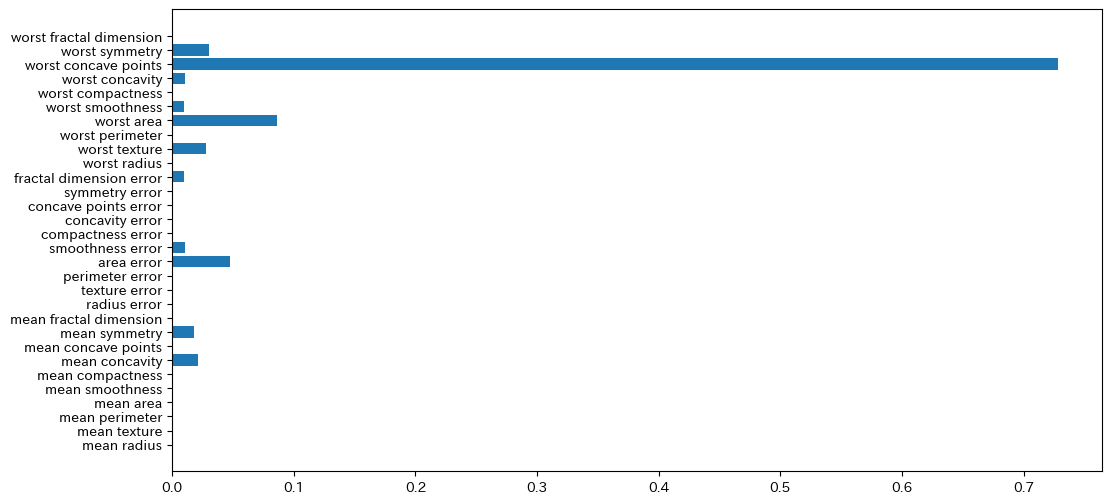

In [14]:
# 決定木による分類と、各説明変数ごとの重要度の表示

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import japanize_matplotlib



df = pd.read_csv('./data/cancer.csv')
X = df[df.columns[1:]]  # target 以外
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0) # データを訓練用とテスト用に分割

print(f'訓練データ数: {len(X_train)}, テストデータ数: {len(X_test)}')

# 決定木による分類

model = DecisionTreeClassifier(random_state=0 ) # 決定木分類器のインスタンスを作成
model.fit(X_train, y_train) # 訓練データを使ってモデル

for column, importance in zip(X_train.columns, model.feature_importances_):
    print(f'{column} {importance:.5f}')
print(sum(model.feature_importances_)," 重要度の合計は1になる ")

# 棒グラフで重要度を表示
plt.figure(figsize=(12, 6))
plt.barh(X_train.columns, model.feature_importances_)
plt.show()



### 決定木のハイパーパラメータ
1. max_depth:
    - 説明: 木の最大深さを指定します。深さが増えるとモデルはより複雑になる。
    - 影響: 過学習を防ぐために、適切な深さを設定することが重要。
2. min_samples_split:
    - 説明: ノードを分割するために必要な最小サンプル数を指定。
    - 影響: 大きな値にすると、より少ない分割が行われ、モデルがシンプルになる。
3. min_samples_leaf:
    - 説明: 葉ノードに必要な最小サンプル数を指定。
    - 影響: 大きな値にすると、木が剪定され、過学習を防ぐのに役立つ。
4. max_features:
    - 説明: 各分割時に考慮する特徴量の最大数を指定。
    - 影響: 特徴量の数を制限することで、モデルの多様性が増し、過学習を防ぐことができる。
5. max_leaf_nodes:
    - 説明: 葉ノードの最大数を指定する。
    - 影響: このパラメータを設定すると、木の複雑さを制限し、過学習を防ぐことができる。
6. min_impurity_decrease:
    - 説明: ノードを分割するために必要な最小不純度減少量を指定する。
    - 影響: 大きな値にすると、分割が少なくなり、木がシンプルになる。

### グリッドサーチ

グリッドサーチは、複数のパラメータの組み合わせを探索し、最も優れた精度の高い組み合わせを探索する手法。

sklearnでは、クロスバリデーションと組み合わさった`GridSearchCV()'が用意されている。


In [15]:
# グリッドサーチで優れたパラメータの組み合わせを探索

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV



df = pd.read_csv('./data/cancer.csv')
X = df[df.columns[1:]]  # target 以外
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0) # データを訓練用とテスト用に分割

print(f'訓練データ数: {len(X_train)}, テストデータ数: {len(X_test)}')

# 決定木による分類

# パラメータの辞書を作成
hparams = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [1,2,3,4,5,6,7,8,9,None],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'min_samples_split': [2, 3, 4, 5, 6, 7, 8],
}


clf = GridSearchCV(DecisionTreeClassifier(), hparams, cv=5) # GridSearchCVのインスタンスを作成

# グリッドサーチで最適なパラメータの組み合わせを探索
clf.fit(X_train, y_train)

# 最良条件の表示と、訓練データとテストデータに対する正解率の表示
best_model = clf.best_estimator_

print('最良条件:\n', best_model)
print('正解率(訓練):', best_model.score(X_train, y_train))
print('正解率(テスト):', best_model.score(X_test, y_test))


訓練データ数: 398, テストデータ数: 171
最良条件:
 DecisionTreeClassifier(max_depth=4, min_samples_leaf=3, min_samples_split=6)
正解率(訓練): 0.9773869346733668
正解率(テスト): 0.9415204678362573
